# Phase 2: Data Efficiency and Scalability (RQ3)

**Objective**: Determine how the amount of training data affects the performance of black-box and white-box lie detection methods, and which approach demonstrates greater sample efficiency across varying dataset sizes.

The experiment evaluates metrics on varying training sizes (100, 200, 500, 1K, 2K, up to 5K) all balanced equally (50/50 Truths/Lies) while testing firmly on a hold-out test set of 1000 pairs. We investigate 10 large datasets capable of scaling this test.

# Colab & Environment Setup

In [2]:
!git clone https://github.com/GeorgeVasile04/llm_lie_detection_black_vs_white_box.git

fatal: destination path 'llm_lie_detection_black_vs_white_box' already exists and is not an empty directory.


In [3]:
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab. Installing dependencies...")
    get_ipython().system('pip install -q transformers accelerate datasets scikit-learn pandas')

    from google.colab import drive
    drive.mount('/content/drive')

    import sys, os

    # Check possible paths for the root repo dir
    possible_paths = [
        '/content/drive/MyDrive/llm_lie_detection_black_vs_white_box/Black_vs_White_Lie_Detection/Data_Efficiency_BB_WB',
        '/content/llm_lie_detection_black_vs_white_box/Black_vs_White_Lie_Detection/Data_Efficiency_BB_WB',
        os.path.join(os.getcwd(), 'Black_vs_White_Lie_Detection', 'Data_Efficiency_BB_WB'),
        os.getcwd()
    ]

    base_proj_path = None
    for path in possible_paths:
        if os.path.exists(path) and os.path.exists(os.path.join(path, 'load_data_efficiency.py')):
            base_proj_path = path
            break

    if base_proj_path:
        os.chdir(base_proj_path)
        print(f"✅ Changed working directory to: {base_proj_path}")
    else:
        print("⚠️ Could not find project directory automatically. Falling back to simple repo clone approach.")
        # If drive sync fails or the folder isn't found, auto-clone the repo as a fallback!
        get_ipython().system('git clone https://github.com/GeorgeVasile04/llm_lie_detection_black_vs_white_box.git /content/repo')
        base_proj_path = '/content/repo/Black_vs_White_Lie_Detection/Data_Efficiency_BB_WB'
        os.chdir(base_proj_path)
        print(f"✅ Downloaded fresh copy from GitHub and moved to: {base_proj_path}")

    # Add Aligned_Comparison_BB_WB to sys path so we can import unmodified core utils
    aligned_path = os.path.abspath(os.path.join(base_proj_path, '..', 'Aligned_Comparison_BB_WB'))
    sys.path.insert(0, aligned_path)
    sys.path.insert(0, base_proj_path)
    # Also add the very root repo to path to ensure repeng loads correctly
    repo_root = os.path.abspath(os.path.join(base_proj_path, '..', '..'))
    sys.path.insert(0, repo_root)

    print(f"✅ Executing in: {os.getcwd()}")

    from huggingface_hub import login
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
    if hf_token: login(token=hf_token)

except ImportError:
    IN_COLAB = False
    import sys, os
    # Local fallback
    current_dir = os.getcwd()
    aligned_path = os.path.abspath(os.path.join(current_dir, '..', 'Aligned_Comparison_BB_WB'))
    if aligned_path not in sys.path:
        sys.path.insert(0, aligned_path)
    if current_dir not in sys.path:
        sys.path.insert(0, current_dir)

Running in Google Colab. Installing dependencies...
Mounted at /content/drive
✅ Changed working directory to: /content/llm_lie_detection_black_vs_white_box/Black_vs_White_Lie_Detection/Data_Efficiency_BB_WB
✅ Executing in: /content/llm_lie_detection_black_vs_white_box/Black_vs_White_Lie_Detection/Data_Efficiency_BB_WB


# Imports & Configuration

In [4]:
import torch
import numpy as np
import pandas as pd
import time
from tqdm.auto import tqdm
import os
import sys

# Add path for White Box models directly
current_dir = os.getcwd()
sys.path.append(os.path.abspath(os.path.join(current_dir, '..', '..')))

if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# Import unmodified feature extractors from Aligned Comparison
from Black_vs_White_Lie_Detection.Aligned_Comparison_BB_WB.wb_activations import load_model, get_activations_for_dataset
from Black_vs_White_Lie_Detection.Aligned_Comparison_BB_WB.bb_logprobs import compute_bb_features_for_dataset

# Import custom Efficiency specific loaders directly matching previous experiment structure (but avoiding A/B complexity)
from load_data_efficiency import load_dataset_efficiency
from Black_vs_White_Lie_Detection.Class_Balance_Impact_BB_WB.wb_probes_imbalance import train_wb_probes_imbalance
from Black_vs_White_Lie_Detection.Class_Balance_Impact_BB_WB.bb_classifier_imbalance import train_bb_classifier_imbalance

MODEL_NAME = "meta-llama/Llama-2-7b-chat-hf"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


# 1. Create Datasets (Efficiency Phase 2)

In [5]:
# We target the 10 datasets that successfully scaled to ~3,000+ balanced unique questions (or close).
DATASETS_CONFIG = [
    "commonsense_qa",
    "race",
    "arc_easy",
    "open_book_qa",
    "boolq",
    "rte",
    "imdb",
    "amazon_polarity",
    "ag_news",
    "dbpedia_14"
]

dataset_dict = {}
N_TEST = 1000

print("Pulling maximizing Class Distribution arrays...\n")
for ds_name in DATASETS_CONFIG:
    print(f"--- Processing {ds_name} ---")

    # Load 1:1 completely balanced sets (Train Split / Max)
    df_raw = load_dataset_efficiency(ds_name, split='all', random_seed=42)

    if len(df_raw) > 0:
        total_questions = len(df_raw) // 2
        print(f"Loaded {total_questions} balanced pairs (total {len(df_raw)} logs).")

        # Keep everything sorted perfectly Truth,False pairs
        # Calculate exactly the limit we can afford. Max 5k trains, min 1k for test.
        # So we want up to 6000 lines (3000 pairs). Let's secure 1000 lines for validation (500 pairs)
        max_possible_pairs = min(3000, total_questions)

        if max_possible_pairs < 500: # Below bare minimum metric capabilities
            print(f"⚠️ {ds_name} lacks enough data (<500 pairs). Skipping.")
            continue

        # Extract limits:
        n_val_pairs = 500
        n_train_pairs = max_possible_pairs - n_val_pairs

        total_val_samples = n_val_pairs * 2
        total_train_samples = n_train_pairs * 2

        # 0 : train_limit => Train (e.g., 5000 records)
        # train_limit : max => Test (e.g., 1000 records)
        df_train_full = df_raw.iloc[:total_train_samples].reset_index(drop=True)
        df_val_full = df_raw.iloc[total_train_samples:total_train_samples+total_val_samples].reset_index(drop=True)

        dataset_dict[ds_name] = {
            "train_full": df_train_full,
            "validation": df_val_full
        }

        print(f"✅ {ds_name} Mapped -> Train Capability: {len(df_train_full)} | Held-Out Test: {len(df_val_full)}\n")
    else:
        print(f"⚠️ {ds_name} failed to load properly. Skipping.")

DATASETS = list(dataset_dict.keys())

Pulling maximizing Class Distribution arrays...

--- Processing commonsense_qa ---


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.25M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/151k [00:00<?, ?B/s]

...

dbpedia_14/train-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

dbpedia_14/test-00000-of-00001.parquet:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Loaded 5697 balanced pairs (total 11394 logs).
✅ dbpedia_14 Mapped -> Train Capability: 5000 | Held-Out Test: 1000



# 2. Load the model

In [6]:
import gc
print("Loading Model...")
model, tokenizer = load_model(MODEL_NAME, device=DEVICE)

Loading Model...
Loading model: meta-llama/Llama-2-7b-chat-hf...


config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

# 3. Extract activations vectors for white box

In [ ]:
WB_BATCH_SIZE = 74 # White Box needs all hidden states, limiting memory
wb_features = {}

for ds_name in tqdm(DATASETS, desc="Dataset WB Extraction"):
    # Dynamically lower batch size heavily for datasets with long text paragraphs!
    if ds_name == "race":
        current_batch_size = 32
    elif ds_name == "imdb":
        current_batch_size = 32
    else:
        current_batch_size = WB_BATCH_SIZE

    df_train = dataset_dict[ds_name]["train_full"]
    df_val = dataset_dict[ds_name]["validation"]

    act_train_full = get_activations_for_dataset(df_train, model, tokenizer, device=DEVICE, batch_size=current_batch_size, show_progress=True)
    act_val_full = get_activations_for_dataset(df_val, model, tokenizer, device=DEVICE, batch_size=current_batch_size, show_progress=True)

    wb_features[ds_name] = {"train_full": act_train_full, "validation": act_val_full}
    print(f"✅ {ds_name} WB -> Train inferences: {len(act_train_full)} | Val inferences: {len(act_val_full)} physically computed.")

    # Clear RAM
    torch.cuda.empty_cache()
    gc.collect()

Dataset WB Extraction:   0%|          | 0/10 [00:00<?, ?it/s]

Extracting activations (batch_size=74):   0%|          | 0/68 [00:00<?, ?it/s]

Extracting activations (batch_size=74):   0%|          | 0/14 [00:00<?, ?it/s]

✅ commonsense_qa WB -> Train inferences: 5000 | Val inferences: 1000 physically computed.


Extracting activations (batch_size=38):   0%|          | 0/132 [00:00<?, ?it/s]

...

Extracting activations (batch_size=74):   0%|          | 0/14 [00:00<?, ?it/s]

✅ ag_news WB -> Train inferences: 5000 | Val inferences: 1000 physically computed.


Extracting activations (batch_size=74):   0%|          | 0/68 [00:00<?, ?it/s]

Extracting activations (batch_size=74):   0%|          | 0/14 [00:00<?, ?it/s]

✅ dbpedia_14 WB -> Train inferences: 5000 | Val inferences: 1000 physically computed.


# Save the vector states from step 3

In [ ]:
# Code to save WB features to disk has been removed as requested.
# wb_features is kept directly in memory.
print("✅ White-Box features are kept in memory (RAM). Skipping disk save.")

# 4. Compute logprobs for black box

In [ ]:
import os
import gc
import pickle
import numpy as np
from tqdm import tqdm
import torch

try:
    probe_base = "../../Black_Box_Lie_Detection/results/probes_groups"
    no_lie_indices = np.load(os.path.join(probe_base, "no_lie_indices.npy"))
    lie_indices = np.load(os.path.join(probe_base, "lie_indices.npy"))
    knowable_indices = np.load(os.path.join(probe_base, "knowable_indices.npy"))
    PAPER_PROBE_INDICES = np.concatenate([no_lie_indices, lie_indices, knowable_indices])
    print(f"✅ Loaded {len(PAPER_PROBE_INDICES)} elicitation questions")
except FileNotFoundError:
    PAPER_PROBE_INDICES = None

bb_features = {}
checkpoint_dir = 'outputs'
os.makedirs(checkpoint_dir, exist_ok=True)

for ds_name in tqdm(DATASETS, desc="Dataset BB Extraction"):
    df_train = dataset_dict[ds_name]["train_full"]
    df_val = dataset_dict[ds_name]["validation"]

    current_bb_batch = 48

    # 🌟 THIS SETS THE SPEED AND SAVES MEMORY FOR THE SPECIFIC DATASET! 🌟
    current_probe_batch = 24 if ds_name == "imdb" else 48

    bb_train_full = compute_bb_features_for_dataset(
        df_train, model, tokenizer, device=DEVICE, batch_size=current_bb_batch, probe_indices=PAPER_PROBE_INDICES, show_progress=True, probe_batch_size=current_probe_batch
    )
    bb_val_full = compute_bb_features_for_dataset(
        df_val, model, tokenizer, device=DEVICE, batch_size=current_bb_batch, probe_indices=PAPER_PROBE_INDICES, show_progress=True, probe_batch_size=current_probe_batch
    )

    def unpack_bb(bb_dict):
        X, Y = [], []
        for r in bb_dict:
            if "bb_features" in r and r["bb_features"]:
                X.append([p["score"] for p in r["bb_features"]])
                Y.append(r["label"])
        return np.array(X), np.array(Y)

    bb_ds_features = {
        "train_full": unpack_bb(bb_train_full),
        "validation": unpack_bb(bb_val_full)
    }

    bb_features[ds_name] = bb_ds_features

    # Save progressively after each dataset INTO ITS OWN FILE
    file_path = os.path.join(checkpoint_dir, f"{ds_name}_bb_features_efficiency.pkl")
    with open(file_path, 'wb') as f:
        pickle.dump(bb_ds_features, f)

    print(f"✅ Saved progressive checkpoint for {ds_name} at {file_path}")

    # Clean GPU and RAM
    torch.cuda.empty_cache()
    gc.collect()

print(f"✅ Successfully finished and saved all BB features separately to {checkpoint_dir}")

# Start from here once step 4 is saved

In [8]:
import os
import pickle
import glob

# Ensure this points to the right path depending on if you are local or in colab
checkpoint_dir = 'outputs'

# wb_features is already in memory from Step 3.
# We only need to load the Black-Box features from disk.

bb_features = {}
bb_files = glob.glob(os.path.join(checkpoint_dir, "*_bb_features_efficiency.pkl"))

print(f"Found {len(bb_files)} Black-Box feature files.")

for file_path in bb_files:
    ds_name = os.path.basename(file_path).replace("_bb_features_efficiency.pkl", "")
    with open(file_path, 'rb') as f:
        bb_features[ds_name] = pickle.load(f)
    print(f"✅ Loaded BB features for {ds_name}")

# We take the intersection to ensure the training loop doesn't crash
# if a dataset is missing from either wb_features or bb_features
DATASETS = [ds for ds in wb_features.keys() if ds in bb_features.keys()]
print(f"\n✅ Ready to evaluate on exactly {len(DATASETS)} datasets: {DATASETS}")

Found 10 Black-Box feature files.
✅ Loaded BB features for ag_news
✅ Loaded BB features for dbpedia_14
✅ Loaded BB features for amazon_polarity
✅ Loaded BB features for imdb
✅ Loaded BB features for commonsense_qa
✅ Loaded BB features for open_book_qa
✅ Loaded BB features for arc_easy
✅ Loaded BB features for race
✅ Loaded BB features for boolq
✅ Loaded BB features for rte

✅ Ready to evaluate on exactly 10 datasets: ['commonsense_qa', 'race', 'arc_easy', 'open_book_qa', 'boolq', 'rte', 'imdb', 'amazon_polarity', 'ag_news', 'dbpedia_14']


# 5. Train Classifiers at Various Data Scales

We perform the training loop for sizes N = [100, 200, 500, 1000, 2000, 5000]. If the dataset doesn't have enough lines for a specific N, it takes the `max_avail` length. We then test strictly on the unchanged held-out 1000 test set.

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, precision_recall_curve
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import os
import sys
import gc
from contextlib import redirect_stdout, redirect_stderr

# Import CV function from imbalance suite
from Black_vs_White_Lie_Detection.Class_Balance_Impact_BB_WB.wb_probes_imbalance import select_best_layer_cv, train_wb_probes_imbalance
from Black_vs_White_Lie_Detection.Class_Balance_Impact_BB_WB.bb_classifier_imbalance import train_bb_classifier_imbalance


def best_recall_at_precision(y_true, y_scores, target_precision=0.90):
    if len(np.unique(y_true)) < 2:
        return 0.0
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    valid_idx = np.where(precisions >= target_precision)[0]
    if len(valid_idx) == 0:
        return 0.0
    return np.max(recalls[valid_idx])

# Include ALL 32 layers for pure CV
LAYER_LIST_CV = list(range(1, 33))
WB_METHODS = ["lr", "dim", "lat", "ccs", "lda", "pca", "pca-g", "lr-g"]
TRAIN_SIZES = [100, 200, 500, 1000, 2000, 5000]

all_results = []
os.makedirs("outputs", exist_ok=True)

for ds_name in DATASETS:
    w_tr_full = wb_features[ds_name]["train_full"]
    w_v = wb_features[ds_name]["validation"]
    
    # BB features
    b_tr_full_X = bb_features[ds_name]["train_full"][0]
    b_tr_full_Y = bb_features[ds_name]["train_full"][1]
    X_val_bb, y_val_bb = bb_features[ds_name]["validation"]

    max_train_avail = len(w_tr_full)
    print(f"\n--- Evaluating {ds_name} on Data Efficiency (Max Avail: {max_train_avail}) ---")

    def calculate_full_metrics(probs_or_logits):
        auc = roc_auc_score(y_val_bb, probs_or_logits) if len(np.unique(y_val_bb)) > 1 else 0.5
        map_score = average_precision_score(y_val_bb, probs_or_logits) if len(np.unique(y_val_bb)) > 1 else 0.5
        brp_90 = best_recall_at_precision(y_val_bb, probs_or_logits, target_precision=0.90)
        return {'AUC': auc, 'MAP': map_score, 'BRP_90': brp_90}

    for size_target in TRAIN_SIZES:
        # We clip training size if max_train_avail < size_target
        actual_size = min(size_target, max_train_avail)

        # Slice Train Arrays
        w_tr_chunk = w_tr_full[:actual_size]
        X_train_bb_chunk = b_tr_full_X[:actual_size]
        y_train_bb_chunk = b_tr_full_Y[:actual_size]

        pbar = tqdm(total=(1 + len(WB_METHODS)), desc=f"{ds_name} (N={size_target})")

        # 1. Train and eval Black Box
        pbar.set_description(f"{ds_name} (N={size_target}) - BB")
        with open(os.devnull, 'w') as f, redirect_stdout(f), redirect_stderr(f):
            bb_model, bb_met_full = train_bb_classifier_imbalance(X_train_bb_chunk, X_val_bb, y_train_bb_chunk, y_val_bb, verbose=False)

        bb_met = calculate_full_metrics(bb_met_full["probs"])
        all_results.append({
            "Dataset": ds_name, "Method": "Black Box", "Algorithm": "BB",
            "Training Size": size_target, "Actual Size Trained": actual_size, "Layer": "N/A",
            "AUC": bb_met["AUC"], "MAP": bb_met["MAP"], "BRP_90": bb_met["BRP_90"]
        })
        pbar.update(1)

        # 2. Train and eval White Box models via CV Layer Selection
        for method in WB_METHODS:
            pbar.set_description(f"{ds_name} (N={size_target}) - WB {method.upper()}")
            best_layer = select_best_layer_cv(w_tr_chunk, layer_list=LAYER_LIST_CV, method=method, verbose=False)
            
            with open(os.devnull, 'w') as f, redirect_stdout(f), redirect_stderr(f):
                _, wb_met = train_wb_probes_imbalance(w_tr_chunk, eval_data=w_v, layer_list=[best_layer], method=method, verbose=False)

            if best_layer in wb_met:
                mA = calculate_full_metrics(wb_met[best_layer]["logits"])
                all_results.append({
                    "Dataset": ds_name, "Method": "White Box", "Algorithm": method.upper(),
                    "Training Size": size_target, "Actual Size Trained": actual_size, "Layer": best_layer,
                    "AUC": mA["AUC"], "MAP": mA["MAP"], "BRP_90": mA["BRP_90"]
                })
            
            pbar.update(1)
            gc.collect()

        pbar.set_description(f"{ds_name} (N={size_target}) - Done")
        pbar.close()

    # ====== SAVE PROGRESS AFTER EACH DATASET COMPLETES ======
    intermediate_df = pd.DataFrame(all_results)
    intermediate_df.to_csv("outputs/data_efficiency_metrics_CV_V2.csv", index=False)
    print(f"💾 Checkpoint: Saved {len(intermediate_df)} total rows so far to outputs/data_efficiency_metrics_CV_V2.csv")

final_df = pd.DataFrame(all_results)
print("\n✅ All datasets finished! Final results saved cleanly to outputs/data_efficiency_metrics_CV_V2.csv")


--- Evaluating commonsense_qa on Data Efficiency (Max Avail: 5000) ---


commonsense_qa (N=100):   0%|          | 0/9 [00:00<?, ?it/s]

commonsense_qa (N=200):   0%|          | 0/9 [00:00<?, ?it/s]

commonsense_qa (N=500):   0%|          | 0/9 [00:00<?, ?it/s]

commonsense_qa (N=1000):   0%|          | 0/9 [00:00<?, ?it/s]

...

dbpedia_14 (N=500):   0%|          | 0/9 [00:00<?, ?it/s]

dbpedia_14 (N=1000):   0%|          | 0/9 [00:00<?, ?it/s]

dbpedia_14 (N=2000):   0%|          | 0/9 [00:00<?, ?it/s]

dbpedia_14 (N=5000):   0%|          | 0/9 [00:00<?, ?it/s]


✅ Saved detailed metric evaluations across training bounds to outputs/data_efficiency_metrics.csv


# 6. Visualization: Data Efficiency Curves

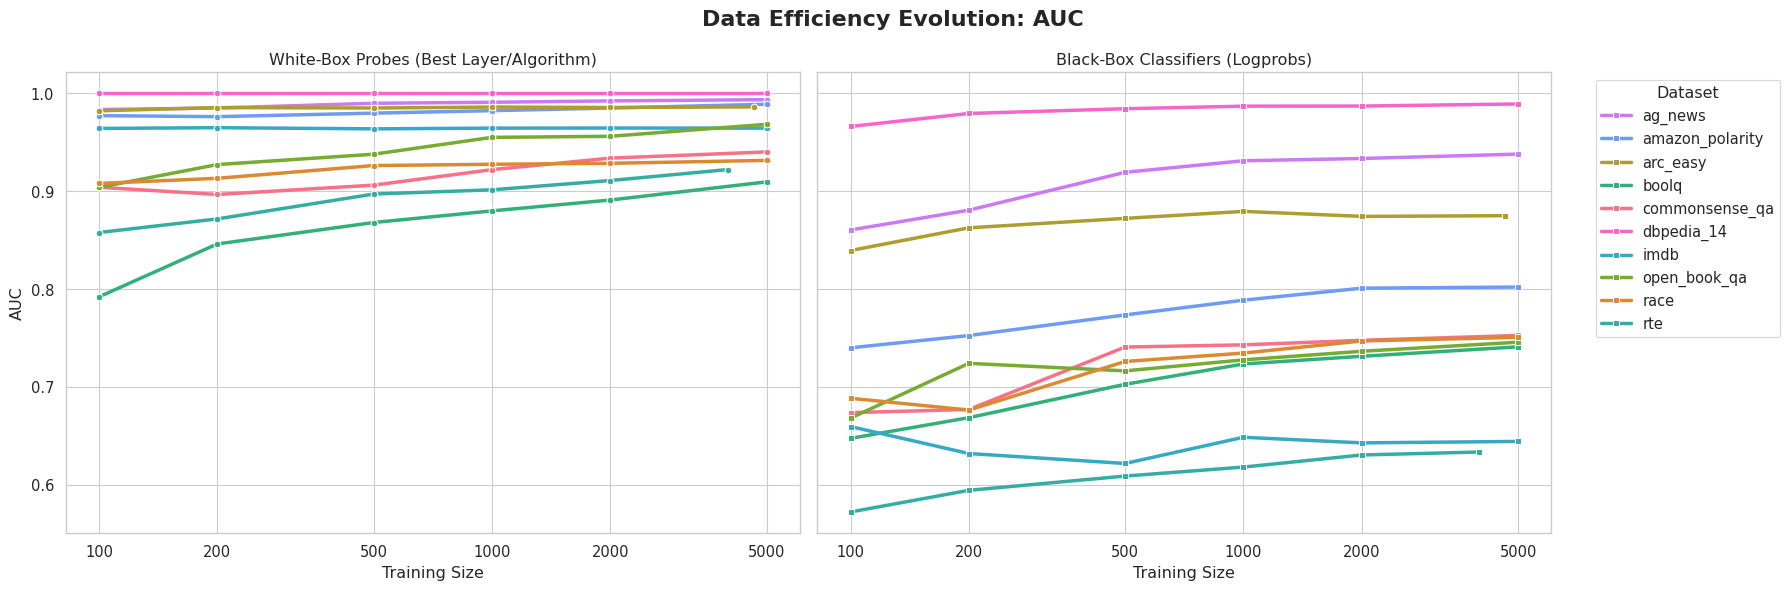

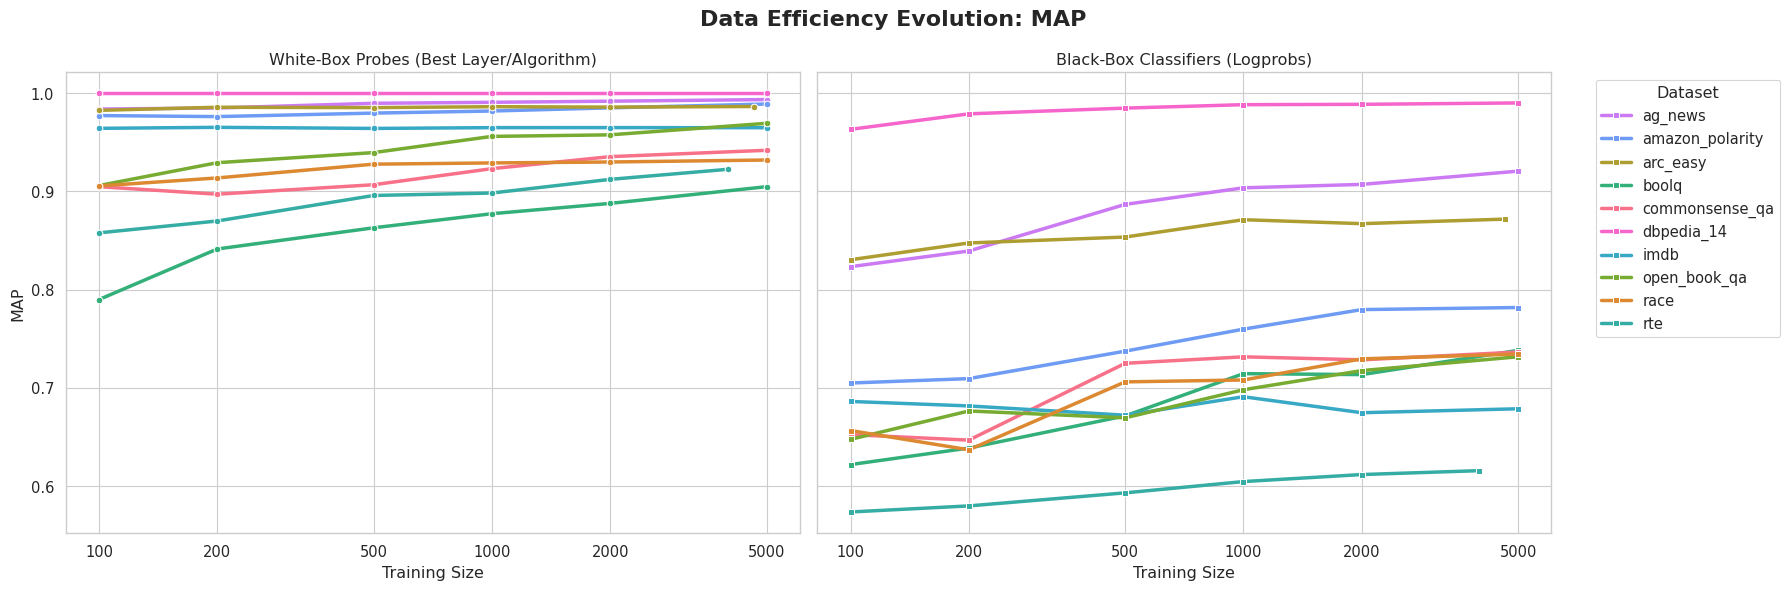

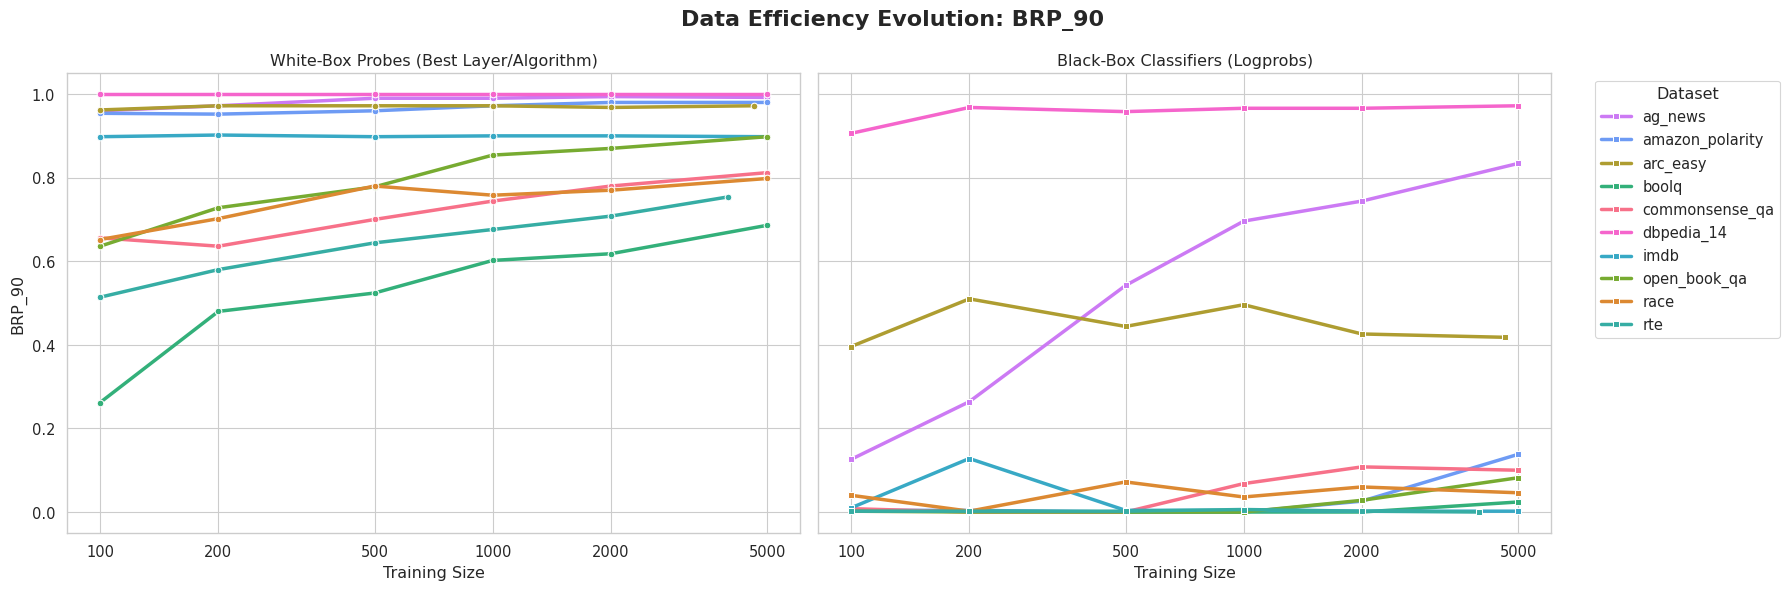


🌟 PHASE 2 EXPERIMENT SETUP COMPLETE: SAVED TO CSV & PLOTTED. 🌟


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the newly generated V2 CSV
if 'final_df' not in locals() or final_df is None:
    final_df = pd.read_csv("outputs/data_efficiency_metrics_CV_V2.csv")

METRICS = ["AUC", "MAP", "BRP_90"]

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

for metric in METRICS:
    plt.figure(figsize=(12, 7))
    
    # Calculate the mean performance of each algorithm at each Training Size (averaging out the Datasets)
    mean_df = final_df.groupby(['Algorithm', 'Training Size'])[metric].mean().reset_index()

    # Plot 1 curve per Algorithm (Total: 9 curves) on one graph, across x=Training Size
    sns.lineplot(data=mean_df, x="Training Size", y=metric, hue="Algorithm",
                 marker="o", linewidth=3.0, palette="tab10")
    
    plt.title(f'Mean Data Efficiency Across All Datasets: {metric}', fontsize=16, fontweight='bold')
    
    # Log scale is vital because jumping from 100 to 5000 is a wide range
    plt.xscale("log")
    
    # Map exact ticks
    ticks = [100, 200, 500, 1000, 2000, 5000]
    plt.xticks(ticks, [str(t) for t in ticks])
    plt.xlabel("Training Size (Log Scale)", fontsize=14)
    plt.ylabel(f"Mean {metric}", fontsize=14)
    
    # Move legend safely outside the plot
    plt.legend(title="Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig(f"outputs/mean_efficiency_curve_{metric}_CV_V2.png", dpi=300, bbox_inches='tight')
    plt.show()

print("\n🌟 PHASE 2 EXPERIMENT COMPLETE: MEAN DATA EFFICIENCY CURVES GENERATED. 🌟")